# Case Study 1 — Univariate Analysis of Annual Mean Temperature

The goal of this exercise is to explore the variable **Annual Mean Temperature (`temp_ann`)** in the EFIplus Mediterranean dataset.

The main objectives are:

- Identify the **four catchments with the highest number of fish sampling sites**.
- Explore the distribution of `temp_ann` using different **univariate visualizations**.
- Create **strip plots, histograms and boxplots**, with four graphs displayed in the same window.
- Build an additional visualization that helps understand the distribution.
- Evaluate the **advantages and disadvantages of each visualization method**.
- Simulate how the **sample mean of `temp_ann` changes with different sample sizes**, using **1000 random samples with replacement**.

## Importing required libraries

In this step we import the main Python libraries needed for data analysis and visualization.

- **pandas** is used to manipulate and analyze tabular data.
- **numpy** is used for numerical operations and simulations.
- **matplotlib** and **seaborn** are used for data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In this step we load the EFIplus Mediterranean dataset into Python using pandas.

The dataset contains information about fish sampling sites and environmental variables.  
The variable of interest for this analysis is **Annual Mean Temperature (`temp_ann`)**.

In [3]:
df = pd.read_csv("data.csv", sep=";")
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


## Exploring the structure of the dataset

Before performing the analysis, it is important to inspect the dataset in order to:

- understand the structure of the data
- check the variable names
- verify the data types
- detect potential missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


## Identifying the four catchments with the highest number of sampling sites

To follow the instructions of the exercise, we first need to determine which catchments contain the largest number of fish sampling sites.

We count the number of observations per catchment and select the four catchments with the highest values.

In [5]:
top4_catchments = df["Catchment_name"].value_counts().head(4)
top4_catchments

Catchment_name
Ebro            736
Galiza-Norte    709
Minho           707
Tejo            509
Name: count, dtype: int64

## Filtering the dataset

After identifying the four catchments with the highest number of observations, we filter the dataset so that the analysis only includes those catchments.

We also remove missing values from the variable `temp_ann` to ensure that the visualizations are based only on valid data.

In [6]:
top4_names = top4_catchments.index.tolist()

df_top4 = df[df["Catchment_name"].isin(top4_names)].copy()

df_top4 = df_top4.dropna(subset=["temp_ann"])

df_top4.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
5,ES_02_0005,40.732830,-2.078003,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


## Descriptive statistics

Before creating visualizations, it is useful to examine some basic descriptive statistics of `temp_ann` for each catchment.

This helps us understand:

- the average temperature
- the variability of values
- the range of observations

In [7]:
summary_stats = (
    df_top4.groupby("Catchment_name")["temp_ann"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

summary_stats

,count,mean,median,std,min,max
Catchment_name,,,,,,
Ebro,715,11.453846,11.9,2.273707,3.9,16.9
Galiza-Norte,709,13.435825,13.5,0.891271,9.2,15.0
Minho,707,11.858416,12.2,1.623498,6.9,15.0
Tejo,493,14.242596,15.0,2.422827,8.0,17.2


## Strip plots

A strip plot displays **individual observations as points**, allowing us to see the distribution of the data and the density of observations.

In this case, we create **four strip plots in a single window**, one for each catchment.

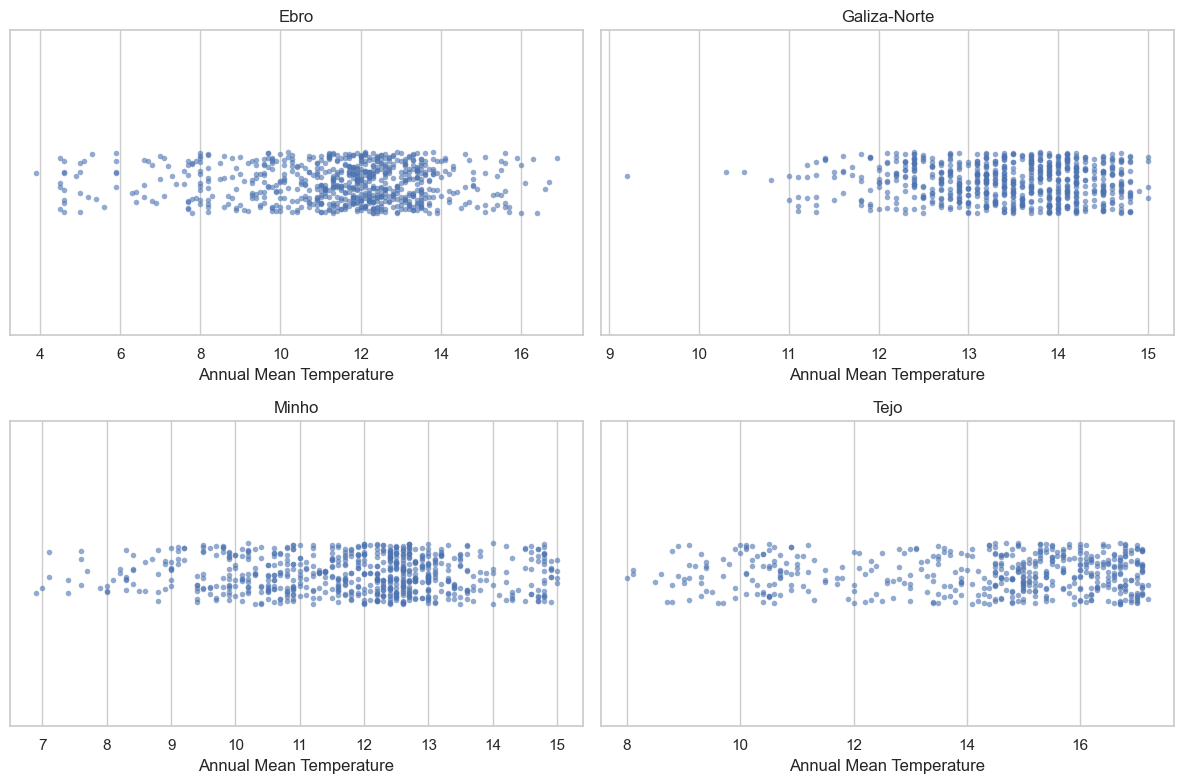

In [8]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, catchment in enumerate(top4_names):
    
    subset = df_top4[df_top4["Catchment_name"] == catchment]
    
    sns.stripplot(
        x=subset["temp_ann"],
        ax=axes[i],
        jitter=True,
        size=4,
        alpha=0.6
    )
    
    axes[i].set_title(catchment)
    axes[i].set_xlabel("Annual Mean Temperature")

plt.tight_layout()
plt.show()

## Histograms

Histograms show the **frequency distribution** of a variable by grouping observations into bins.

This type of visualization helps identify:

- the shape of the distribution
- possible skewness
- concentration of values

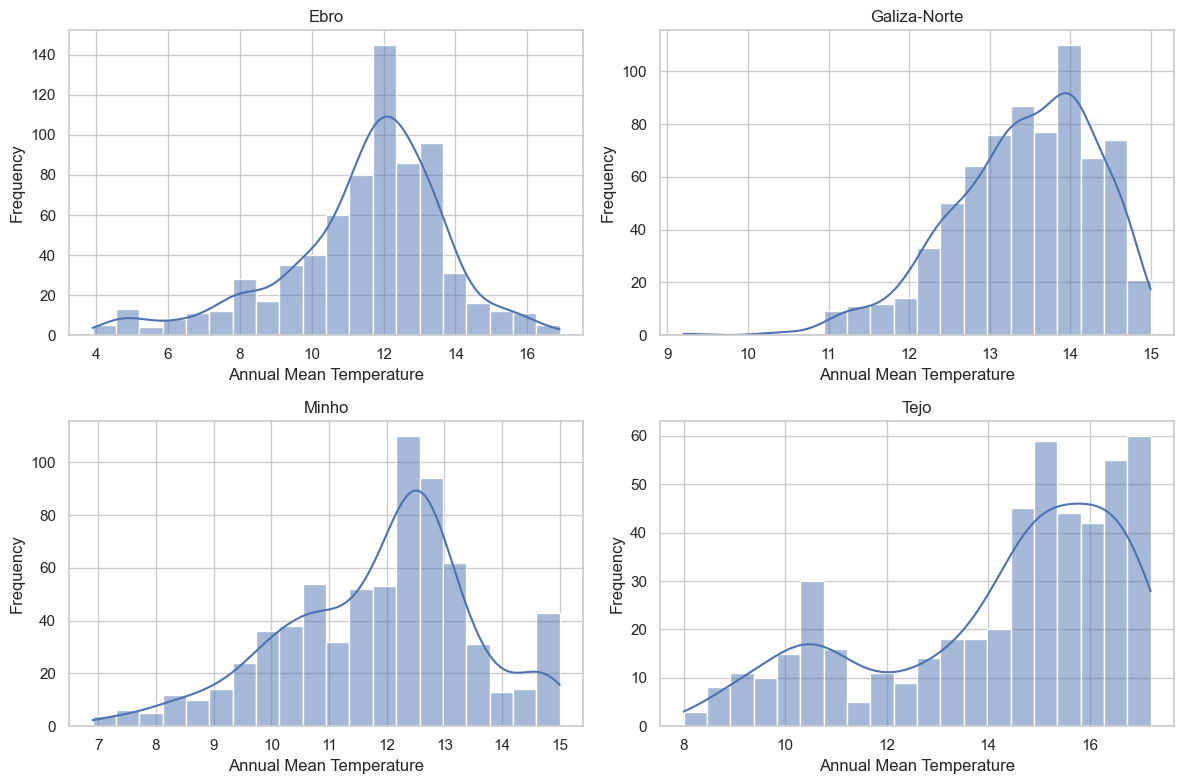

In [9]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, catchment in enumerate(top4_names):
    
    subset = df_top4[df_top4["Catchment_name"] == catchment]
    
    sns.histplot(
        subset["temp_ann"],
        bins=20,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(catchment)
    axes[i].set_xlabel("Annual Mean Temperature")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Boxplots

Boxplots provide a **compact summary of the distribution** of a variable.

They display:

- the median
- the interquartile range
- potential outliers

Boxplots are particularly useful for comparing distributions across groups.

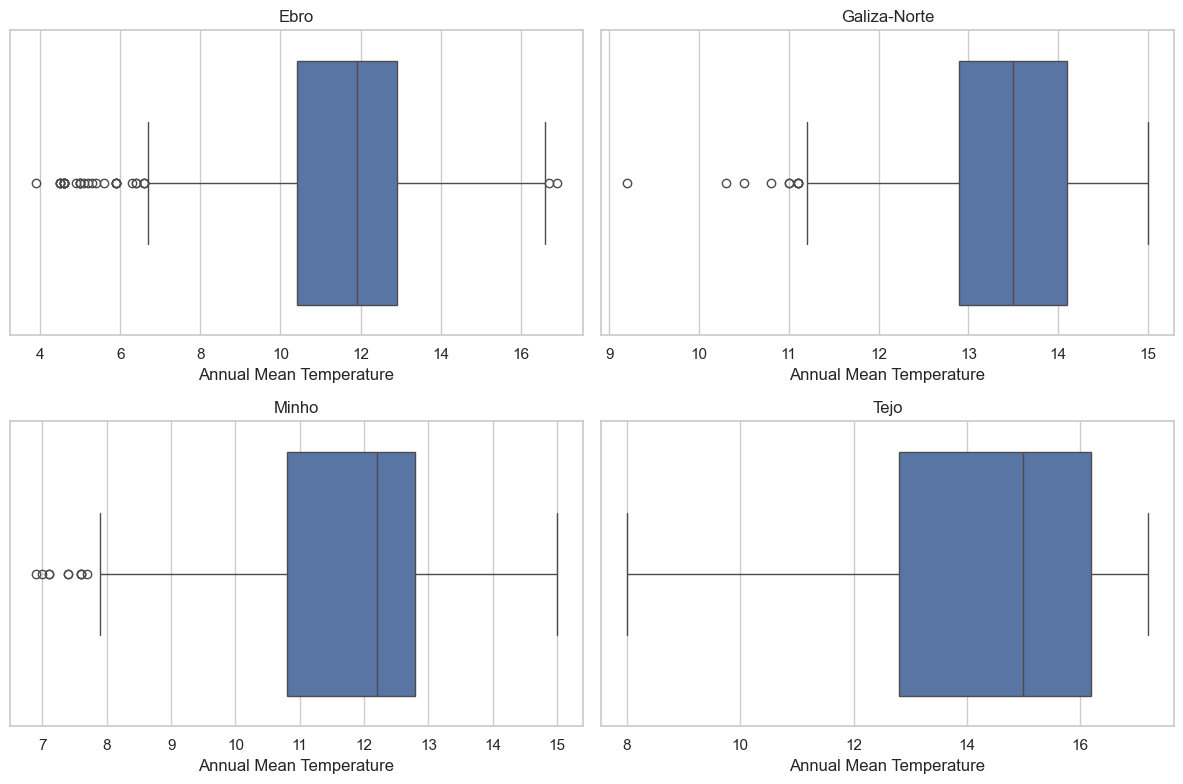

In [10]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, catchment in enumerate(top4_names):
    
    subset = df_top4[df_top4["Catchment_name"] == catchment]
    
    sns.boxplot(
        x=subset["temp_ann"],
        ax=axes[i]
    )
    
    axes[i].set_title(catchment)
    axes[i].set_xlabel("Annual Mean Temperature")

plt.tight_layout()
plt.show()

## Additional visualization: violin plot

A violin plot combines aspects of boxplots and density plots.  
It shows both the **summary statistics** and the **shape of the distribution**.

This visualization can provide additional insight into how the data are distributed.

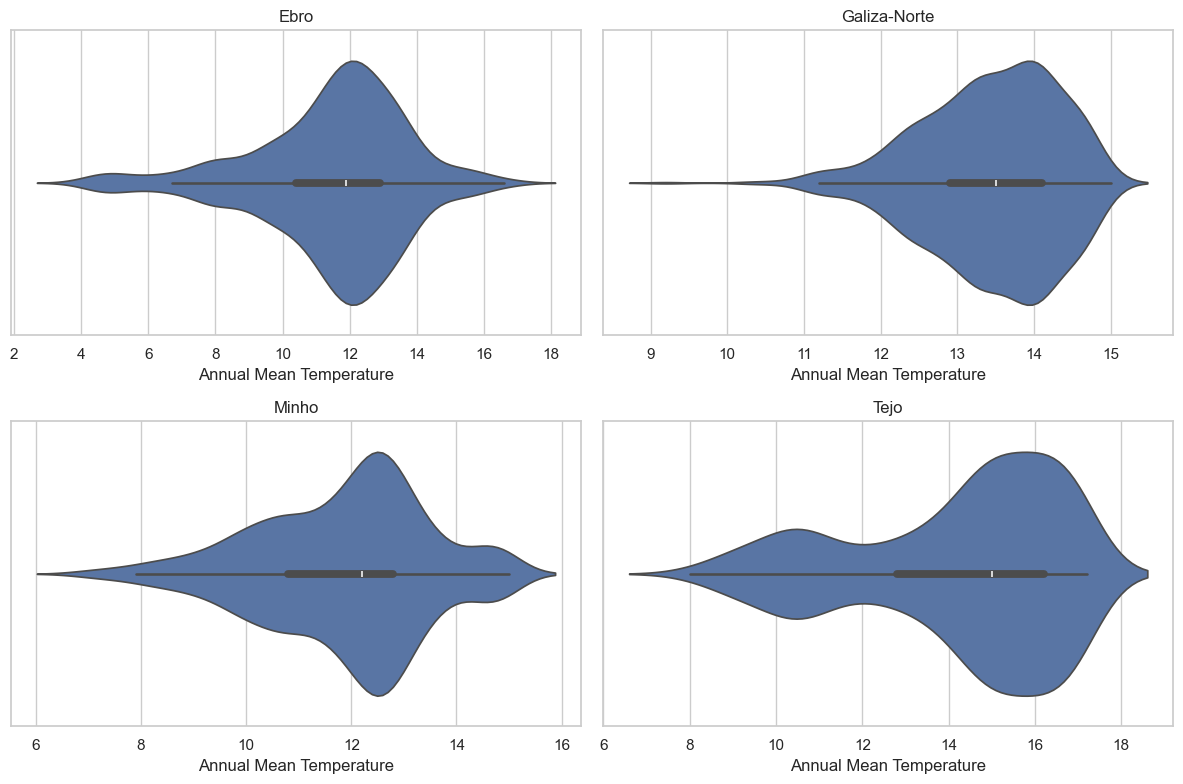

In [11]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, catchment in enumerate(top4_names):
    
    subset = df_top4[df_top4["Catchment_name"] == catchment]
    
    sns.violinplot(
        x=subset["temp_ann"],
        ax=axes[i],
        inner="box"
    )
    
    axes[i].set_title(catchment)
    axes[i].set_xlabel("Annual Mean Temperature")

plt.tight_layout()
plt.show()

## Simulation: how the sample mean changes with sample size

To understand how the estimate of the mean improves with larger samples, we perform a simulation.

The procedure is the following:

1. Take **1000 random samples with replacement** from the dataset.
2. Repeat this process for different **sample sizes**.
3. Compute the **mean of temp_ann for each sample**.
4. Visualize how the variability of the sample mean decreases as the sample size increases.

This illustrates an important statistical concept: **the law of large numbers**.

In [12]:
temp = df["temp_ann"].dropna().values

sample_sizes = [10,50,100,150,200,250,300,500,1000]

results = []

for size in sample_sizes:
    
    for i in range(1000):
        
        sample = np.random.choice(temp, size=size, replace=True)
        sample_mean = sample.mean()
        
        results.append({
            "sample_size": size,
            "sample_mean": sample_mean
        })

results_df = pd.DataFrame(results)